# MolParetoBO — Technical Report & Workflow Notebook

**University of Salerno · Master in AI for Drug Discovery** 
**Project 06** · Surrogate-Assisted Multi-Objective Molecular Optimization 
**Student:** Ali Ghiami

> **Tip:** jump to [Section 8c — Interactive Control Panel](#8c-interactive-control-panel-check-that-it-runs). 
> **Tools:** [Appendix B](#appendix-b--tools--software-detailed). 
> **Slides / PDF:** `MolParetoBO_Slides.pdf` · `MolParetoBO_Report.pdf`

## Contents (clickable)

1. [Environment setup](#0-environment-setup-local--google-colab)
2. [Project goal](#1-project-goal-and-scientific-rationale)
3. [Design decisions](#2-locked-design-decisions)
4. [Seed molecule](#3-seed-molecule--ibuprofen)
5. [Endpoints](#4-endpoint-definitions-oracle)
6. [Mutations + filters](#5-molecular-mutations--suitability-filters)
7. [Interactive demo](#5b-interactive-demo)
8. [Surrogate model](#6-surrogate-model)
9. [Pareto front](#7-pareto-front)
10. [Acquisition + loop](#8-acquisition-and-iterative-active-loop)
11. [Interactive Control Panel](#8c-interactive-control-panel-check-that-it-runs)
12. [Critical discussion](#9-critical-discussion)
13. [Extensions (GP / NSGA-II / EHVI)](#10-optional-extensions-gp--nsga-ii--ehvi)
14. [Appendix A — How to run](#appendix-a--how-to-run)
15. [Appendix B — Tools](#appendix-b--tools--software-detailed)

| Section | Content | Status |
|---------|---------|--------|
| 0–8 | Full MolParetoBO loop + widgets | done |
| 8c | Interactive Control Panel | done |
| 9 | Critical discussion | done |
| 10 | Extensions (GP, NSGA-II, EHVI) | done |
| App. B | Tools & software (detailed) | done |


## 0. Environment setup (local + Google Colab)

Run this cell first. It detects Colab, installs packages if needed, and prepares folders.


In [1]:
# --- Environment: works on local Anaconda and Google Colab ---
from pathlib import Path
import sys
import subprocess
import warnings
warnings.filterwarnings("ignore")

def in_colab() -> bool:
 try:
  import google.colab # noqa: F401
  return True
 except ImportError:
  return False

IN_COLAB = in_colab()
print("Runtime:", "Google Colab" if IN_COLAB else "Local")

def ensure_pkg(import_name, pip_name=None):
 pip_name = pip_name or import_name
 try:
  __import__(import_name)
 except ImportError:
  print(f"Installing {pip_name} ...")
  subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

# Core deps (idempotent)
ensure_pkg("rdkit", "rdkit")
ensure_pkg("pandas")
ensure_pkg("sklearn", "scikit-learn")
ensure_pkg("matplotlib")
ensure_pkg("ipywidgets")

if IN_COLAB:
 try:
  from google.colab import output
  output.enable_custom_widget_manager()
 except Exception as e:
  print("Widget manager note:", e)

from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, QED, Crippen, Lipinski, AllChem
from rdkit.Chem import rdMolDescriptors
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
FIG = ROOT / "figures"
DATA = ROOT / "data"
FIG.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

# Portable SA Score import (Contrib path differs by install)
import rdkit as _rdkit
_SA_CANDIDATES = [
 Path(_rdkit.__file__).resolve().parent / "Contrib" / "SA_Score",
 Path("/opt/anaconda3/lib/python3.12/site-packages/rdkit/Contrib/SA_Score"),
]
for _p in _SA_CANDIDATES:
 if _p.exists():
  sys.path.insert(0, str(_p))
  break
import sascorer

print("RDKit OK · folders:", FIG, DATA)


Runtime: Local


RDKit OK · folders: /Users/alighiami/Documents/Master/figures /Users/alighiami/Documents/Master/data


## 1. Project goal and scientific rationale

Drug discovery is **multi-objective**: candidates must balance drug-likeness, solubility, lipophilicity, synthetic accessibility and toxicity-related risk. A single weighted score hides trade-offs.

**MolParetoBO** (student prototype) combines:

1. Molecular mutations (RDKit)
2. Suitability / drug-likeness filters
3. An oracle scoring several endpoints
4. A surrogate that approximates the oracle cheaply
5. Pareto selection + acquisition (next sections)

> Expensive oracles cannot evaluate every mutant — surrogates + active selection address that bottleneck.


## 2. Locked design decisions

| Item | Decision | Rationale |
|------|----------|-----------|
| Seed count (phase 1) | **One molecule** | Build the pipeline |
| Seed | **Ibuprofen** | Small, drug-like, public, clear sites |
| SMILES | `CC(C)Cc1ccc(cc1)C(C)C(=O)O` | Canonical structure |
| Endpoints | **5** | QED↑, SA↓, logP~2.5, logS↑, Tox↓ |
| Mutations | Methyl add/remove + ring F/Cl/OH/Me | Interpretable |
| Filters | Sanitize, MW 150–450, heavy atoms ≥8, QED ≥0.3 | Suitability after mutation |
| SoftMining | Seed-agnostic workflow | Can swap in SoftMining/MIND seeds later |


## 3. Seed molecule — ibuprofen

Structural regions: **isobutyl tail**, **benzene ring**, **α-methyl**, **carboxylic acid** (acid edits deferred).


Seed: ibuprofen
SMILES: CC(C)Cc1ccc(cc1)C(C)C(=O)O
Formula: C13H18O2
MW: 206.28


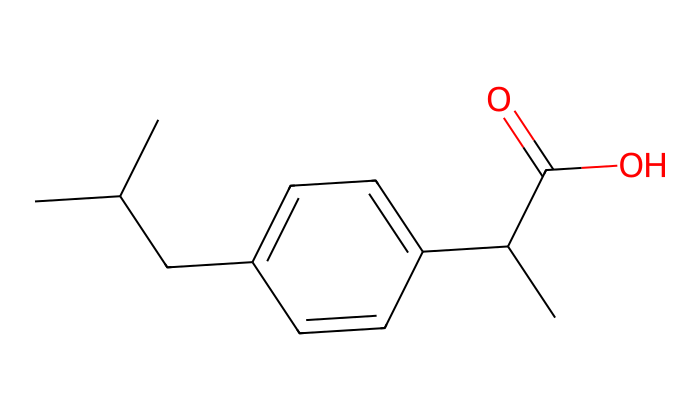

Saved: /Users/alighiami/Documents/Master/figures/01_ibuprofen_atom_indices.png


,idx,symbol,degree,neighbors,is_aromatic,total_Hs
0,0,C,1,"(1,)",False,3
1,1,C,3,"(0, 2, 3)",False,1
2,2,C,1,"(1,)",False,3
3,3,C,2,"(1, 4)",False,2
4,4,C,3,"(3, 5, 9)",True,0
5,5,C,2,"(4, 6)",True,1
6,6,C,2,"(5, 7)",True,1
7,7,C,3,"(6, 8, 10)",True,0


In [2]:
SEED_NAME = "ibuprofen"
SEED_SMILES = "CC(C)Cc1ccc(cc1)C(C)C(=O)O"
seed = Chem.MolFromSmiles(SEED_SMILES)
assert seed is not None, "Invalid seed SMILES"

print(f"Seed: {SEED_NAME}")
print(f"SMILES: {SEED_SMILES}")
print(f"Formula: {rdMolDescriptors.CalcMolFormula(seed)}")
print(f"MW: {Descriptors.MolWt(seed):.2f}")

img = Draw.MolToImage(seed, size=(700, 420), includeAtomNumbers=True)
img_path = FIG / "01_ibuprofen_atom_indices.png"
img.save(img_path)
display(img)
print("Saved:", img_path)

rows = []
for a in seed.GetAtoms():
 rows.append({
  "idx": a.GetIdx(),
  "symbol": a.GetSymbol(),
  "degree": a.GetDegree(),
  "neighbors": tuple(n.GetIdx() for n in a.GetNeighbors()),
  "is_aromatic": a.GetIsAromatic(),
  "total_Hs": a.GetTotalNumHs(),
 })
atom_df = pd.DataFrame(rows)
display(atom_df.head(8))
atom_df.to_csv(DATA / "ibuprofen_atoms.csv", index=False)


## 4. Endpoint definitions (oracle)

| # | Endpoint | Goal | Implementation |
|---|----------|------|----------------|
| 1 | QED | maximize | RDKit QED |
| 2 | SA | minimize | RDKit SA Score |
| 3 | logP | prefer ~2.5 | Crippen (+ fitness `-|logP-2.5|`) |
| 4 | logS | maximize | ESOL-style predicted logS |
| 5 | Tox | minimize | Transparent heuristic proxy |

Toxicity is a **teaching proxy**, not a validated toxicology model.


In [3]:
LOGP_TARGET = 2.5

def esol_logs(mol):
 mw = Descriptors.MolWt(mol)
 logp = Crippen.MolLogP(mol)
 rotb = Lipinski.NumRotatableBonds(mol)
 n_rings = rdMolDescriptors.CalcNumRings(mol) or 1
 arom_frac = Lipinski.NumAromaticRings(mol) / max(1, n_rings)
 return float(0.16 - 0.63 * logp - 0.0062 * mw + 0.066 * rotb - 0.74 * arom_frac)


def toxicity_proxy(mol):
 score = 0.0
 for smarts in ["[N+](=O)[O-]", "C(=O)Cl", "[As]", "N=N", "[S;D2][S;D2]", "C#N"]:
  patt = Chem.MolFromSmarts(smarts)
  if patt and mol.HasSubstructMatch(patt):
   score += 0.25
 logp = Crippen.MolLogP(mol)
 mw = Descriptors.MolWt(mol)
 if logp > 5:
  score += 0.15 * (logp - 5)
 if mw > 500:
  score += 0.002 * (mw - 500)
 if mol.HasSubstructMatch(Chem.MolFromSmarts("c[NH2]")):
  score += 0.2
 return float(min(score, 2.0))


def score_molecule(mol, name=None, smiles=None):
 if mol is None:
  return None
 logp = Crippen.MolLogP(mol)
 return {
  "name": name,
  "smiles": smiles or Chem.MolToSmiles(mol),
  "qed": float(QED.qed(mol)),
  "sa": float(sascorer.calculateScore(mol)),
  "logp": float(logp),
  "logp_fit": float(-abs(logp - LOGP_TARGET)),
  "logs": esol_logs(mol),
  "tox": toxicity_proxy(mol),
  "mw": float(Descriptors.MolWt(mol)),
 }

seed_scores = score_molecule(seed, name=SEED_NAME, smiles=SEED_SMILES)
display(pd.DataFrame([seed_scores]).T.rename(columns={0: "ibuprofen"}))
pd.DataFrame([seed_scores]).to_csv(DATA / "seed_scores.csv", index=False)


,ibuprofen
name,ibuprofen
smiles,CC(C)Cc1ccc(cc1)C(C)C(=O)O
qed,0.8216
sa,2.191755
logp,3.0732
logp_fit,-0.5732
logs,-3.531083
tox,0.0
mw,206.285


## 5. Molecular mutations + suitability filters

### Operators
1. **Methyl add / remove**
2. **Ring substitution** (F, Cl, OH, Me)

### Suitability check (after mutation)
Every mutant must: sanitize · deduplicate · MW 150–450 · heavy atoms ≥ 8 · QED ≥ threshold (default 0.3).


In [4]:
def sanitize_or_none(mol):
 if mol is None:
  return None
 try:
  Chem.SanitizeMol(mol)
  return Chem.MolFromSmiles(Chem.MolToSmiles(mol))
 except Exception:
  return None


def add_methyl(mol, atom_idx):
 rw = Chem.RWMol(Chem.Mol(mol))
 atom = rw.GetAtomWithIdx(atom_idx)
 if atom.GetTotalNumHs() < 1:
  return None
 new_idx = rw.AddAtom(Chem.Atom(6))
 rw.AddBond(atom_idx, new_idx, Chem.BondType.SINGLE)
 return sanitize_or_none(rw.GetMol())


def remove_methyl(mol, methyl_idx):
 atom = mol.GetAtomWithIdx(methyl_idx)
 if atom.GetSymbol() != "C" or atom.GetDegree() != 1:
  return None
 if atom.GetNeighbors()[0].GetSymbol() != "C":
  return None
 rw = Chem.RWMol(Chem.Mol(mol))
 rw.RemoveAtom(methyl_idx)
 return sanitize_or_none(rw.GetMol())


def substitute_aromatic_H(mol, atom_idx, group):
 atom = mol.GetAtomWithIdx(atom_idx)
 if not atom.GetIsAromatic() or atom.GetTotalNumHs() < 1:
  return None
 rw = Chem.RWMol(Chem.Mol(mol))
 if group == "F":
  idx = rw.AddAtom(Chem.Atom(9))
 elif group == "Cl":
  idx = rw.AddAtom(Chem.Atom(17))
 elif group == "OH":
  idx = rw.AddAtom(Chem.Atom(8))
 elif group == "Me":
  idx = rw.AddAtom(Chem.Atom(6))
 else:
  return None
 rw.AddBond(atom_idx, idx, Chem.BondType.SINGLE)
 return sanitize_or_none(rw.GetMol())


def passes_filters(mol, qed_min=0.3, mw_min=150, mw_max=450):
 if mol is None:
  return False
 mw = Descriptors.MolWt(mol)
 if not (mw_min <= mw <= mw_max):
  return False
 if mol.GetNumHeavyAtoms() < 8:
  return False
 try:
  if QED.qed(mol) < qed_min:
   return False
 except Exception:
  return False
 return True


def generate_mutants(seed_mol, seed_smiles=SEED_SMILES, qed_min=0.3):
 records, seen = [], {Chem.MolToSmiles(seed_mol)}

 for atom in seed_mol.GetAtoms():
  if atom.GetSymbol() != "C" or atom.GetTotalNumHs() < 1:
   continue
  skip = False
  for n in atom.GetNeighbors():
   bond = seed_mol.GetBondBetweenAtoms(atom.GetIdx(), n.GetIdx())
   if n.GetSymbol() == "O" and bond.GetBondType() == Chem.BondType.DOUBLE:
    skip = True
    break
  if skip:
   continue
  mut = add_methyl(seed_mol, atom.GetIdx())
  if mut is None:
   continue
  smi = Chem.MolToSmiles(mut)
  if smi in seen:
   continue
  seen.add(smi)
  records.append({"mutation": f"methyl_add@{atom.GetIdx()}", "smiles": smi, "mol": mut,
      "kept": passes_filters(mut, qed_min=qed_min)})

 for atom in seed_mol.GetAtoms():
  if atom.GetSymbol() == "C" and atom.GetDegree() == 1:
   mut = remove_methyl(seed_mol, atom.GetIdx())
   if mut is None:
    continue
   smi = Chem.MolToSmiles(mut)
   if smi in seen:
    continue
   seen.add(smi)
   records.append({"mutation": f"methyl_remove@{atom.GetIdx()}", "smiles": smi, "mol": mut,
       "kept": passes_filters(mut, qed_min=qed_min)})

 for atom in seed_mol.GetAtoms():
  if not (atom.GetIsAromatic() and atom.GetSymbol() == "C" and atom.GetTotalNumHs() >= 1):
   continue
  for group in ["F", "Cl", "OH", "Me"]:
   mut = substitute_aromatic_H(seed_mol, atom.GetIdx(), group)
   if mut is None:
    continue
   smi = Chem.MolToSmiles(mut)
   if smi in seen:
    continue
   seen.add(smi)
   records.append({"mutation": f"ring_{group}@{atom.GetIdx()}", "smiles": smi, "mol": mut,
       "kept": passes_filters(mut, qed_min=qed_min)})
 return records


def expand_one_generation(mols_with_labels, qed_min=0.3, max_parents=8):
 # Apply mutations to a few parents to enlarge the surrogate dataset.
 out, seen = [], set()
 for parent_smi, parent_mol in mols_with_labels[:max_parents]:
  seen.add(parent_smi)
  for r in generate_mutants(parent_mol, seed_smiles=parent_smi, qed_min=qed_min):
   if r["smiles"] in seen:
    continue
   seen.add(r["smiles"])
   r["mutation"] = f"gen2|{r['mutation']}"
   out.append(r)
 return out


mutants = generate_mutants(seed)
print(f"Gen-1 unique mutants: {len(mutants)} | kept: {sum(r['kept'] for r in mutants)}")

# Second generation from a few kept mutants (more data for surrogate)
kept_parents = [(r["smiles"], r["mol"]) for r in mutants if r["kept"]]
gen2 = expand_one_generation(kept_parents, max_parents=5)
print(f"Gen-2 unique mutants: {len(gen2)} | kept: {sum(r['kept'] for r in gen2)}")

all_mutants = mutants + gen2


Gen-1 unique mutants: 15 | kept: 15
Gen-2 unique mutants: 76 | kept: 76


,mutation,smiles,kept,qed,sa,logp,logp_fit,logs,tox,mw
0,SEED,CC(C)Cc1ccc(cc1)C(C)C(=O)O,True,0.821600,2.191755,3.07320,-0.57320,-3.531083,0.0,206.285
1,methyl_add@0,CCC(C)Cc1ccc(C(C)C(=O)O)cc1,True,0.824656,2.602277,3.46330,-0.96330,-3.797813,0.0,220.312
2,methyl_add@1,CC(C(=O)O)c1ccc(CC(C)(C)C)cc1,True,0.846553,2.398213,3.46330,-0.96330,-3.929813,0.0,220.312
3,methyl_add@3,CC(C(=O)O)c1ccc(C(C)C(C)C)cc1,True,0.840808,2.730693,3.63420,-1.13420,-3.971480,0.0,220.312
4,methyl_add@5,Cc1cc(C(C)C(=O)O)ccc1CC(C)C,True,0.844175,2.457593,3.38162,-0.88162,-3.812355,0.0,220.312
5,methyl_add@6,Cc1cc(CC(C)C)ccc1C(C)C(=O)O,True,0.844175,2.463972,3.38162,-0.88162,-3.812355,0.0,220.312
6,methyl_add@10,CC(C)Cc1ccc(C(C)(C)C(=O)O)cc1,True,0.845334,1.917153,3.24730,-0.74730,-3.727733,0.0,220.312
7,methyl_add@11,CCC(C(=O)O)c1ccc(CC(C)C)cc1,True,0.824656,2.269086,3.46330,-0.96330,-3.797813,0.0,220.312
8,methyl_remove@0,CCCc1ccc(C(C)C(=O)O)cc1,True,0.796029,2.123914,2.82720,-0.32720,-3.289136,0.0,192.258
9,methyl_remove@11,CC(C)Cc1ccc(CC(=O)O)cc1,True,0.795450,1.558585,2.51220,-0.01220,-3.090686,0.0,192.258


Saved: /Users/alighiami/Documents/Master/data/mutants_scored.csv
Total rows: 92 | kept: 92


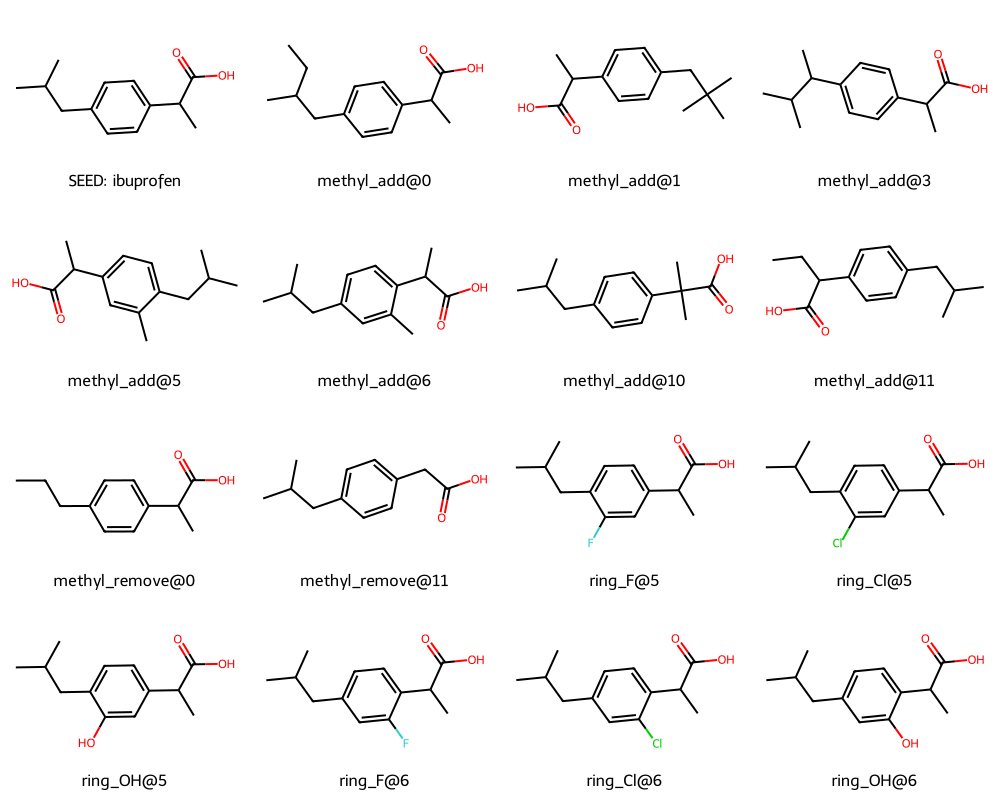

Saved: /Users/alighiami/Documents/Master/figures/02_mutation_gallery.png


In [5]:
# Score all mutants
scored = []
for r in all_mutants:
 s = score_molecule(r["mol"], name=r["mutation"], smiles=r["smiles"])
 s["mutation"] = r["mutation"]
 s["kept"] = r["kept"]
 scored.append(s)

mut_df = pd.DataFrame(scored)
seed_row = seed_scores.copy()
seed_row["mutation"] = "SEED"
seed_row["kept"] = True
full_df = pd.concat([pd.DataFrame([seed_row]), mut_df], ignore_index=True)

cols = ["mutation", "smiles", "kept", "qed", "sa", "logp", "logp_fit", "logs", "tox", "mw"]
display(full_df[cols].head(12))
full_df[cols].to_csv(DATA / "mutants_scored.csv", index=False)
print("Saved:", DATA / "mutants_scored.csv")
print("Total rows:", len(full_df), "| kept:", int(full_df['kept'].sum()))

kept_mols = [seed] + [r["mol"] for r in mutants if r["kept"]]
kept_legends = ["SEED: ibuprofen"] + [r["mutation"] for r in mutants if r["kept"]]
n_show = min(16, len(kept_mols))
grid = Draw.MolsToGridImage(kept_mols[:n_show], molsPerRow=4, subImgSize=(250, 200), legends=kept_legends[:n_show])
display(grid)
grid_path = FIG / "02_mutation_gallery.png"
if hasattr(grid, "save"):
 grid.save(grid_path)
elif hasattr(grid, "data"):
 grid_path.write_bytes(grid.data)
print("Saved:", grid_path)


## 5b. Interactive demo ()

Use the widgets below to confirm the pipeline is **runnable** without editing code:

1. Adjust the **QED filter** threshold 
2. Click **Run pipeline** 
3. Inspect counts, a molecule drawing, and endpoint scores 
4. Optionally pick a SMILES from the dropdown to inspect

> On Colab: if widgets do not appear, run *Runtime → Restart and run all* after the setup cell.


In [6]:
import ipywidgets as widgets

out_box = widgets.Output()
qed_slider = widgets.FloatSlider(value=0.3, min=0.1, max=0.7, step=0.05, description="QED min",
         style={"description_width": "80px"}, layout=widgets.Layout(width="420px"))
gen2_check = widgets.Checkbox(value=True, description="Include 2nd-generation mutants")
run_btn = widgets.Button(description="Run pipeline", button_style="success", icon="play",
       layout=widgets.Layout(width="160px"))
smiles_dd = widgets.Dropdown(options=[], description="Inspect", layout=widgets.Layout(width="520px"))
inspect_btn = widgets.Button(description="Draw selected", button_style="info",
        layout=widgets.Layout(width="160px"))

_state = {"full_df": None, "mol_map": {}}


def _run_pipeline(_=None):
 with out_box:
  clear_output(wait=True)
  qmin = float(qed_slider.value)
  print(f"Running… QED ≥ {qmin:.2f}")
  m1 = generate_mutants(seed, qed_min=qmin)
  records = list(m1)
  if gen2_check.value:
   parents = [(r["smiles"], r["mol"]) for r in m1 if r["kept"]]
   records += expand_one_generation(parents, qed_min=qmin, max_parents=5)

  rows, mol_map = [], {}
  seed_s = score_molecule(seed, name="SEED", smiles=SEED_SMILES)
  seed_s["mutation"] = "SEED"
  seed_s["kept"] = True
  rows.append(seed_s)
  mol_map[SEED_SMILES] = seed

  for r in records:
   s = score_molecule(r["mol"], name=r["mutation"], smiles=r["smiles"])
   s["mutation"] = r["mutation"]
   s["kept"] = r["kept"]
   rows.append(s)
   mol_map[r["smiles"]] = r["mol"]

  df = pd.DataFrame(rows)
  _state["full_df"] = df
  _state["mol_map"] = mol_map
  smiles_dd.options = [(f"{row.mutation} | QED={row.qed:.2f}", row.smiles) for row in df.itertuples()]

  kept = int(df["kept"].sum())
  display(HTML(
   f"<div style='font-family:sans-serif;padding:8px 12px;background:#eef6f2;"
   f"border-left:4px solid #0b6e4f;border-radius:6px'>"
   f"<b>Pipeline OK</b> · molecules={len(df)} · kept={kept} · rejected={len(df)-kept}"
   f"</div>"
  ))
  display(df[["mutation", "kept", "qed", "sa", "logp", "logs", "tox", "mw"]].head(10).round(3))
  display(Draw.MolToImage(seed, size=(320, 220)))
  print("Select a molecule below and click Draw selected.")


def _draw_selected(_=None):
 with out_box:
  smi = smiles_dd.value
  mol = _state["mol_map"].get(smi)
  if mol is None:
   print("Nothing selected yet — run the pipeline first.")
   return
  df = _state["full_df"]
  row = df.loc[df.smiles == smi].iloc[0]
  print(f"{row.mutation}\n{smi}")
  print(f"QED={row.qed:.3f} SA={row.sa:.3f} logP={row.logp:.3f} logS={row.logs:.3f} tox={row.tox:.3f}")
  display(Draw.MolToImage(mol, size=(360, 260)))


run_btn.on_click(_run_pipeline)
inspect_btn.on_click(_draw_selected)

controls = widgets.VBox([
 widgets.HTML("<b>Interactive check</b>"),
 widgets.HBox([qed_slider, gen2_check]),
 widgets.HBox([run_btn, inspect_btn]),
 smiles_dd,
 out_box,
])
display(controls)
_run_pipeline() # auto-run once so the demo is immediately visible


## 6. Surrogate model

We train a **Random Forest** on **Morgan fingerprints** to predict the five oracle endpoints.

- Features: Morgan radius 2, 2048 bits 
- Targets: QED, SA, logP, logS, Tox 
- Data: seed + kept mutants (gen-1 and gen-2) 
- Split: 75% train / 25% test (small-N demo — expect limited generalization; we discuss this honestly)

The surrogate is the cheap stand-in for the oracle inside later acquisition loops.


Surrogate dataset: 92 molecules × 2048 bits → 5 targets


,endpoint,MAE,R2
0,qed,0.008,0.791
1,sa,0.108,0.787
2,logp,0.155,0.766
3,logs,0.128,0.759
4,tox,0.000,1.000


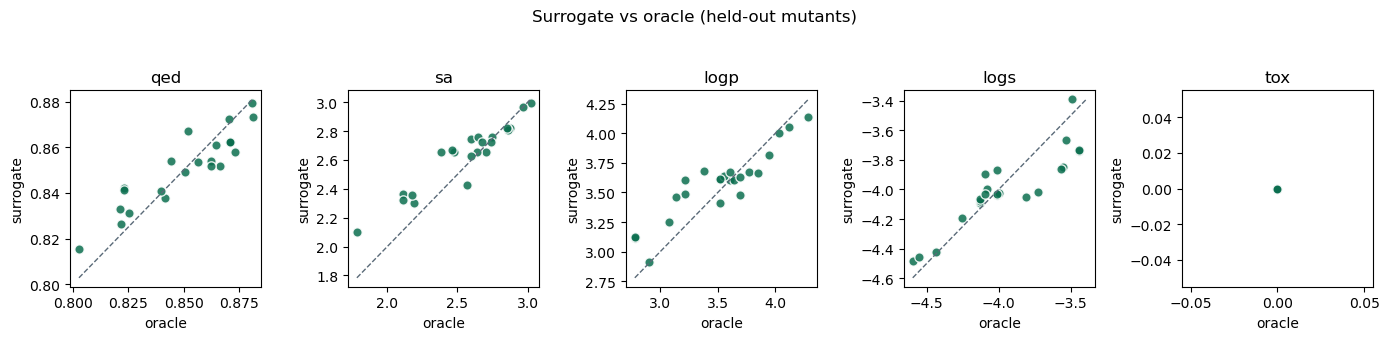

Saved: /Users/alighiami/Documents/Master/figures/03_surrogate_parity.png


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

TARGETS = ["qed", "sa", "logp", "logs", "tox"]


from rdkit.Chem import rdFingerprintGenerator
_MFP = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def morgan_fp(mol, n_bits=2048, radius=2):
 fp = _MFP.GetFingerprint(mol)
 arr = np.zeros((n_bits,), dtype=np.int8)
 from rdkit.DataStructs import ConvertToNumpyArray
 ConvertToNumpyArray(fp, arr)
 return arr


# Use kept molecules only (suitable ones)
train_pool = full_df[full_df["kept"]].copy().reset_index(drop=True)
mols = [Chem.MolFromSmiles(s) for s in train_pool["smiles"]]
X = np.vstack([morgan_fp(m) for m in mols])
Y = train_pool[TARGETS].values.astype(float)

print(f"Surrogate dataset: {len(train_pool)} molecules × {X.shape[1]} bits → {len(TARGETS)} targets")

# If very small, still demonstrate with a hold-out; document limitation
test_size = 0.25 if len(train_pool) >= 12 else 0.2
X_train, X_test, Y_train, Y_test, idx_tr, idx_te = train_test_split(
 X, Y, train_pool.index.values, test_size=test_size, random_state=42
)

model = MultiOutputRegressor(
 RandomForestRegressor(
  n_estimators=200,
  max_depth=8,
  min_samples_leaf=1,
  random_state=42,
  n_jobs=-1,
 )
)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

metrics = []
for i, t in enumerate(TARGETS):
 metrics.append({
  "endpoint": t,
  "MAE": mean_absolute_error(Y_test[:, i], Y_pred[:, i]),
  "R2": r2_score(Y_test[:, i], Y_pred[:, i]),
 })
metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(3))
metrics_df.to_csv(DATA / "surrogate_metrics.csv", index=False)

# Predicted vs true plots
fig, axes = plt.subplots(1, len(TARGETS), figsize=(14, 3.2))
for i, (ax, t) in enumerate(zip(axes, TARGETS)):
 ax.scatter(Y_test[:, i], Y_pred[:, i], c="#0b6e4f", alpha=0.85, edgecolors="white", s=45)
 lo = min(Y_test[:, i].min(), Y_pred[:, i].min())
 hi = max(Y_test[:, i].max(), Y_pred[:, i].max())
 ax.plot([lo, hi], [lo, hi], "--", color="#5a6a78", lw=1)
 ax.set_title(t)
 ax.set_xlabel("oracle")
 ax.set_ylabel("surrogate")
fig.suptitle("Surrogate vs oracle (held-out mutants)", y=1.05)
fig.tight_layout()
fig_path = FIG / "03_surrogate_parity.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

# Save predictions table
pred_df = train_pool.loc[idx_te, ["mutation", "smiles"] + TARGETS].copy()
for i, t in enumerate(TARGETS):
 pred_df[f"pred_{t}"] = Y_pred[:, i]
pred_df.to_csv(DATA / "surrogate_holdout_predictions.csv", index=False)


In [8]:
# Widget: ask the surrogate about any kept SMILES
surr_out = widgets.Output()
surr_dd = widgets.Dropdown(
 options=[(f"{r.mutation}", r.smiles) for r in train_pool.itertuples()],
 description="Molecule",
 layout=widgets.Layout(width="520px"),
)
surr_btn = widgets.Button(description="Predict endpoints", button_style="primary",
       layout=widgets.Layout(width="180px"))


def _predict(_=None):
 with surr_out:
  clear_output(wait=True)
  smi = surr_dd.value
  mol = Chem.MolFromSmiles(smi)
  true = train_pool.loc[train_pool.smiles == smi, TARGETS].iloc[0]
  pred = model.predict(morgan_fp(mol).reshape(1, -1))[0]
  tab = pd.DataFrame({"endpoint": TARGETS, "oracle": true.values, "surrogate": pred,
       "abs_err": np.abs(true.values - pred)})
  display(HTML("<b>Surrogate check</b> (oracle vs prediction)"))
  display(tab.round(3))
  display(Draw.MolToImage(mol, size=(320, 220)))


surr_btn.on_click(_predict)
display(widgets.VBox([
 widgets.HTML("<b>Query the surrogate</b>"),
 widgets.HBox([surr_dd, surr_btn]),
 surr_out,
]))
_predict()


## 6.1 Interim conclusions (surrogate)

- Fingerprint → Random Forest is a solid **baseline** surrogate for this proof of concept.
- With a still-small chemical neighbourhood, R² can be unstable — that is expected and improves when the iterative loop adds labelled molecules.
- Widgets above let you verify both **generation/filtering** and **surrogate prediction** interactively.

Next: **Pareto front**, **acquisition**, and a short **active-learning loop**.


## 7. Pareto front

We compare molecules in **objective space**, not with one weighted score.

### Objectives (all treated as *maximize* after sign flip)

| Raw endpoint | Used as | Reason |
|--------------|---------|--------|
| QED | +QED | higher drug-likeness |
| SA | −SA | lower synthetic difficulty |
| logP | −\|logP − 2.5\| | prefer moderate lipophilicity |
| logS | +logS | higher predicted solubility |
| Tox | −Tox | lower toxicity proxy |

A molecule is **non-dominated** (on the approximate Pareto front) if no other kept molecule is better or equal in all objectives and strictly better in at least one.


In [9]:
# --- Pareto utilities ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

_MFP = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

OBJ_COLS = ["qed", "sa", "logp", "logs", "tox"]


def objective_matrix(df: pd.DataFrame) -> np.ndarray:
 # Return (n, 5) matrix where higher is always better.
 qed = df["qed"].to_numpy(float)
 sa = -df["sa"].to_numpy(float)
 logp_fit = -np.abs(df["logp"].to_numpy(float) - LOGP_TARGET)
 logs = df["logs"].to_numpy(float)
 tox = -df["tox"].to_numpy(float)
 return np.column_stack([qed, sa, logp_fit, logs, tox])


def is_pareto_efficient(Y: np.ndarray) -> np.ndarray:
 # Boolean mask of non-dominated points (maximize all columns).
 n = Y.shape[0]
 keep = np.ones(n, dtype=bool)
 for i in range(n):
  if not keep[i]:
   continue
  # i is dominated if some other j is >= in all objs and > in one
  dom = np.all(Y >= Y[i], axis=1) & np.any(Y > Y[i], axis=1)
  dom[i] = False
  if np.any(dom):
   keep[i] = False
 return keep


def hypervolume_2d(points_2d: np.ndarray, ref: np.ndarray) -> float:
 # Simple 2D hypervolume for monitoring (maximize both axes).
 pts = points_2d[np.all(points_2d > ref, axis=1)]
 if len(pts) == 0:
  return 0.0
 order = np.argsort(-pts[:, 0]) # descending obj1
 pts = pts[order]
 hv, best_y = 0.0, ref[1]
 for x, y in pts:
  if y > best_y:
   hv += (x - ref[0]) * (y - best_y)
   best_y = y
 return float(max(hv, 0.0))


pareto_df = full_df[full_df["kept"]].copy().reset_index(drop=True)
Y_obj = objective_matrix(pareto_df)
mask = is_pareto_efficient(Y_obj)
pareto_df["on_front"] = mask
front = pareto_df[pareto_df["on_front"]].copy()

print(f"Kept molecules: {len(pareto_df)}")
print(f"Pareto front size: {int(mask.sum())}")
display(front[["mutation", "smiles", "qed", "sa", "logp", "logs", "tox", "mw"]].round(3).head(15))
front.to_csv(DATA / "pareto_front.csv", index=False)
pareto_df.to_csv(DATA / "pareto_labelled.csv", index=False)


Kept molecules: 92
Pareto front size: 20


,mutation,smiles,qed,sa,logp,logs,tox,mw
2,methyl_add@1,CC(C(=O)O)c1ccc(CC(C)(C)C)cc1,0.847,2.398,3.463,-3.930,0.0,220.312
6,methyl_add@10,CC(C)Cc1ccc(C(C)(C)C(=O)O)cc1,0.845,1.917,3.247,-3.728,0.0,220.312
8,methyl_remove@0,CCCc1ccc(C(C)C(=O)O)cc1,0.796,2.124,2.827,-3.289,0.0,192.258
9,methyl_remove@11,CC(C)Cc1ccc(CC(=O)O)cc1,0.795,1.559,2.512,-3.091,0.0,192.258
10,ring_F@5,CC(C)Cc1ccc(C(C)C(=O)O)cc1F,0.852,2.477,3.212,-3.730,0.0,224.275
11,ring_Cl@5,CC(C)Cc1ccc(C(C)C(=O)O)cc1Cl,0.871,2.461,3.727,-4.156,0.0,240.730
15,ring_OH@6,CC(C)Cc1ccc(C(C)C(=O)O)c(O)c1,0.823,2.597,2.779,-3.445,0.0,222.284
27,gen2|methyl_remove@10,CCC(C)Cc1ccc(CC(=O)O)cc1,0.804,2.162,2.902,-3.357,0.0,206.285
35,gen2|methyl_add@1,CC(C)(C)Cc1ccc(C(C)(C)C(=O)O)cc1,0.867,2.111,3.637,-4.126,0.0,234.339
39,gen2|methyl_remove@0,CC(C)(C)Cc1ccc(CC(=O)O)cc1,0.825,1.783,2.902,-3.489,0.0,206.285


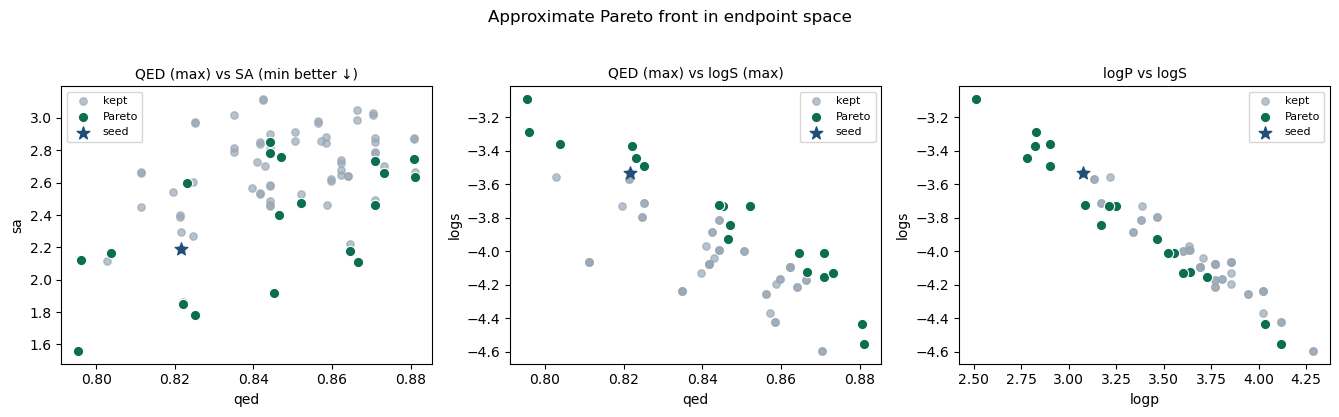

Saved: /Users/alighiami/Documents/Master/figures/04_pareto_front.png
2D hypervolume proxy (QED, -SA) vs ref [0.3, -5.0]: 1.9595


In [10]:
# Pareto visualization (2D projections)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

pairs = [
 ("qed", "sa", "QED (max) vs SA (min better ↓)"),
 ("qed", "logs", "QED (max) vs logS (max)"),
 ("logp", "logs", "logP vs logS"),
]

for ax, (x, y, title) in zip(axes, pairs):
 ax.scatter(pareto_df[x], pareto_df[y], c="#9aa8b5", s=28, alpha=0.7, label="kept")
 ax.scatter(front[x], front[y], c="#0b6e4f", s=55, edgecolors="white", linewidths=0.8, label="Pareto")
 # mark seed
 seed_row = pareto_df[pareto_df["mutation"] == "SEED"]
 if len(seed_row):
  ax.scatter(seed_row[x], seed_row[y], c="#1f4e79", s=90, marker="*", label="seed")
 ax.set_xlabel(x)
 ax.set_ylabel(y)
 ax.set_title(title, fontsize=10)
 ax.legend(fontsize=8, loc="best")

fig.suptitle("Approximate Pareto front in endpoint space", y=1.03)
fig.tight_layout()
fig_path = FIG / "04_pareto_front.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

# Monitor a simple 2D hypervolume on (QED, -SA)
pts2 = np.column_stack([front["qed"].to_numpy(float), -front["sa"].to_numpy(float)])
ref2 = np.array([0.3, -5.0]) # reference point (worse than typical candidates)
hv = hypervolume_2d(pts2, ref2)
print(f"2D hypervolume proxy (QED, -SA) vs ref {ref2.tolist()}: {hv:.4f}")


## 8. Acquisition and iterative active loop

### Acquisition idea
Candidates are ranked by a simple score that balances:

1. **Predicted quality** — mean of normalized surrogate objectives (higher better) 
2. **Uncertainty** — tree-ensemble std (explore where the model is unsure) 
3. **Diversity** — Tanimoto distance to already labelled molecules 

\[
\text{acquisition} = \alpha \cdot \text{quality} + \beta \cdot \text{uncertainty} + \gamma \cdot \text{diversity}
\]

Default: α=0.5, β=0.3, γ=0.2. Top-\(k\) molecules are sent to the **oracle**, labels are added, the surrogate is **retrained**, and the Pareto front is updated.

This is a simplified stand-in for full qEHVI — appropriate for a student proof of concept.


In [11]:
# --- Acquisition helpers ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor


def fp_array(mol):
 fp = _MFP.GetFingerprint(mol)
 arr = np.zeros((2048,), dtype=np.int8)
 DataStructs.ConvertToNumpyArray(fp, arr)
 return arr


def tanimoto(a, b):
 return float(np.sum(a & b) / max(1, np.sum(a | b)))


def normalize_obj_rows(Y):
 # Column-wise min-max to [0,1]; constant columns -> 0.5.
 Y = Y.astype(float).copy()
 for j in range(Y.shape[1]):
  lo, hi = Y[:, j].min(), Y[:, j].max()
  if hi - lo < 1e-12:
   Y[:, j] = 0.5
  else:
   Y[:, j] = (Y[:, j] - lo) / (hi - lo)
 return Y


def fit_surrogate(df_lab):
 mols = [Chem.MolFromSmiles(s) for s in df_lab["smiles"]]
 X = np.vstack([fp_array(m) for m in mols])
 Y = df_lab[OBJ_COLS].values.astype(float)
 model = MultiOutputRegressor(
  RandomForestRegressor(
   n_estimators=120, max_depth=8, random_state=42, n_jobs=-1
  )
 )
 model.fit(X, Y)
 return model


def predict_with_uncertainty(model, X):
 # Mean prediction + mean tree std across outputs.
 means = []
 stds = []
 for est in model.estimators_: # one RF per target
  tree_preds = np.stack([t.predict(X) for t in est.estimators_], axis=0)
  means.append(tree_preds.mean(axis=0))
  stds.append(tree_preds.std(axis=0))
 mean = np.column_stack(means) # (n, n_targets)
 std = np.column_stack(stds)
 return mean, std


def acquisition_scores(model, cand_df, labelled_fps, alpha=0.5, beta=0.3, gamma=0.2):
 mols = [Chem.MolFromSmiles(s) for s in cand_df["smiles"]]
 X = np.vstack([fp_array(m) for m in mols])
 mean, std = predict_with_uncertainty(model, X)

 # Convert predictions to maximize-objectives then normalize
 # mean columns: qed, sa, logp, logs, tox
 Ymax = np.column_stack([
  mean[:, 0],
  -mean[:, 1],
  -np.abs(mean[:, 2] - LOGP_TARGET),
  mean[:, 3],
  -mean[:, 4],
 ])
 qual = normalize_obj_rows(Ymax).mean(axis=1)
 unc = std.mean(axis=1)
 if unc.max() > unc.min():
  unc = (unc - unc.min()) / (unc.max() - unc.min())
 else:
  unc = np.zeros_like(unc)

 div = []
 for x in X:
  if len(labelled_fps) == 0:
   div.append(1.0)
  else:
   sims = [tanimoto(x, lf) for lf in labelled_fps]
   div.append(1.0 - float(np.mean(sims)))
 div = np.asarray(div, float)
 if div.max() > div.min():
  div = (div - div.min()) / (div.max() - div.min())

 score = alpha * qual + beta * unc + gamma * div
 out = cand_df.copy()
 out["acq_quality"] = qual
 out["acq_uncertainty"] = unc
 out["acq_diversity"] = div
 out["acquisition"] = score
 return out.sort_values("acquisition", ascending=False)


In [12]:
# --- Iterative active optimization loop ---
rng = np.random.default_rng(42)

# Pool = all kept molecules; start labelled with SEED + a few random mutants
pool = full_df[full_df["kept"]].drop_duplicates("smiles").reset_index(drop=True)
seed_mask = pool["mutation"] == "SEED"
init_extra = pool.loc[~seed_mask].sample(n=min(8, (~seed_mask).sum()), random_state=42).index.tolist()
labelled_idx = set(pool.index[seed_mask].tolist() + init_extra)

history = []
N_ITERS = 5
BATCH = 4

for it in range(1, N_ITERS + 1):
 lab = pool.loc[sorted(labelled_idx)].copy()
 unlab = pool.drop(index=list(labelled_idx)).copy()
 if len(unlab) == 0:
  print("No unlabelled candidates left.")
  break

 model_it = fit_surrogate(lab)
 lab_fps = [fp_array(Chem.MolFromSmiles(s)) for s in lab["smiles"]]
 ranked = acquisition_scores(model_it, unlab, lab_fps)
 batch = ranked.head(BATCH)

 # "Oracle evaluation" = use already computed oracle columns (simulates calling the oracle)
 for idx in batch.index:
  labelled_idx.add(idx)

 lab2 = pool.loc[sorted(labelled_idx)].copy()
 Y2 = objective_matrix(lab2)
 front_mask = is_pareto_efficient(Y2)
 front2 = lab2[front_mask]
 hv = hypervolume_2d(
  np.column_stack([front2["qed"].to_numpy(float), -front2["sa"].to_numpy(float)]),
  np.array([0.3, -5.0]),
 )
 history.append({
  "iter": it,
  "n_labelled": len(lab2),
  "front_size": int(front_mask.sum()),
  "hv_qed_negSA": hv,
  "batch_mutations": "; ".join(batch["mutation"].astype(str).tolist()),
  "batch_mean_acq": float(batch["acquisition"].mean()),
 })
 print(f"Iter {it}: labelled={len(lab2)} | front={int(front_mask.sum())} | HV={hv:.4f}")
 print(" selected:", batch["mutation"].tolist())

hist_df = pd.DataFrame(history)
display(hist_df)
hist_df.to_csv(DATA / "optimization_history.csv", index=False)

# Final front after loop
final_lab = pool.loc[sorted(labelled_idx)].copy()
final_lab["on_front"] = is_pareto_efficient(objective_matrix(final_lab))
final_front = final_lab[final_lab["on_front"]]
final_front.to_csv(DATA / "pareto_front_after_loop.csv", index=False)
print(f"Final labelled={len(final_lab)} | final front={len(final_front)}")


Iter 1: labelled=13 | front=9 | HV=1.8235
 selected: ['gen2|methyl_remove@0', 'gen2|methyl_remove@5', 'gen2|ring_Cl@10', 'gen2|methyl_remove@12']


Iter 2: labelled=17 | front=10 | HV=1.8298
 selected: ['gen2|methyl_add@1', 'gen2|ring_Cl@7', 'ring_Cl@5', 'gen2|ring_Cl@7']


Iter 3: labelled=21 | front=12 | HV=1.8443
 selected: ['gen2|methyl_add@11', 'gen2|methyl_add@4', 'gen2|methyl_add@1', 'gen2|ring_Cl@2']


Iter 4: labelled=25 | front=12 | HV=1.8443
 selected: ['gen2|methyl_add@0', 'gen2|methyl_add@12', 'gen2|methyl_add@9', 'gen2|methyl_add@9']


Iter 5: labelled=29 | front=13 | HV=1.8443
 selected: ['gen2|methyl_remove@0', 'gen2|methyl_remove@3', 'methyl_remove@0', 'gen2|ring_OH@10']


,iter,n_labelled,front_size,hv_qed_negSA,batch_mutations,batch_mean_acq
0,1,13,9,1.823515,gen2|methyl_remove@0; gen2|methyl_remove@5; ge...,0.691293
1,2,17,10,1.829835,gen2|methyl_add@1; gen2|ring_Cl@7; ring_Cl@5; ...,0.595348
2,3,21,12,1.844349,gen2|methyl_add@11; gen2|methyl_add@4; gen2|me...,0.661508
3,4,25,12,1.844349,gen2|methyl_add@0; gen2|methyl_add@12; gen2|me...,0.687578
4,5,29,13,1.844349,gen2|methyl_remove@0; gen2|methyl_remove@3; me...,0.658671


Final labelled=29 | final front=13


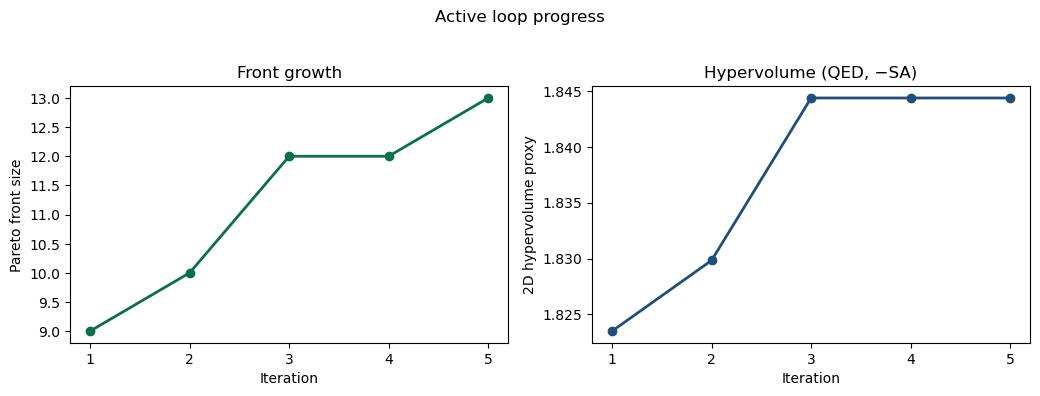

Saved: /Users/alighiami/Documents/Master/figures/05_optimization_progress.png


,mutation,qed,sa,logp,logs,tox,mw
8,methyl_remove@0,0.796,2.124,2.827,-3.289,0.0,192.258
11,ring_Cl@5,0.871,2.461,3.727,-4.156,0.0,240.730
23,gen2|methyl_add@9,0.844,2.487,3.637,-3.994,0.0,234.339
27,gen2|methyl_remove@10,0.804,2.162,2.902,-3.357,0.0,206.285
35,gen2|methyl_add@1,0.867,2.111,3.637,-4.126,0.0,234.339
39,gen2|methyl_remove@0,0.825,1.783,2.902,-3.489,0.0,206.285
40,gen2|ring_F@6,0.873,2.702,3.602,-4.129,0.0,238.302
44,gen2|ring_Cl@7,0.881,2.637,4.117,-4.555,0.0,254.757
62,gen2|methyl_add@4,0.865,2.179,3.556,-4.009,0.0,234.339
75,gen2|ring_Cl@10,0.881,2.753,4.035,-4.438,0.0,254.757


In [13]:
# Optimization progress plots
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].plot(hist_df["iter"], hist_df["front_size"], "o-", color="#0b6e4f", lw=2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Pareto front size")
axes[0].set_title("Front growth")
axes[0].set_xticks(hist_df["iter"])

axes[1].plot(hist_df["iter"], hist_df["hv_qed_negSA"], "o-", color="#1f4e79", lw=2)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("2D hypervolume proxy")
axes[1].set_title("Hypervolume (QED, −SA)")
axes[1].set_xticks(hist_df["iter"])

fig.suptitle("Active loop progress", y=1.03)
fig.tight_layout()
fig_path = FIG / "05_optimization_progress.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

# Show final front molecules
display(final_front[["mutation", "qed", "sa", "logp", "logs", "tox", "mw"]].round(3))


## 8b. Interactive acquisition demo (interactive)

Pick batch size and acquisition weights, then run one selection step on the current unlabelled pool.


In [14]:
import ipywidgets as widgets
from IPython.display import clear_output, display, HTML

acq_out = widgets.Output()
batch_slider = widgets.IntSlider(value=4, min=1, max=8, description="Batch k",
         style={"description_width": "70px"})
a_slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.1, description="α quality")
b_slider = widgets.FloatSlider(value=0.3, min=0.0, max=1.0, step=0.1, description="β uncert.")
c_slider = widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.1, description="γ divers.")
acq_btn = widgets.Button(description="Select batch", button_style="success", icon="filter",
       layout=widgets.Layout(width="150px"))


def _run_acq(_=None):
 with acq_out:
  clear_output(wait=True)
  # Renormalize weights
  w = np.array([a_slider.value, b_slider.value, c_slider.value], float)
  if w.sum() <= 0:
   print("Set at least one weight > 0")
   return
  w = w / w.sum()
  lab = pool.loc[sorted(labelled_idx)].copy()
  unlab = pool.drop(index=list(labelled_idx)).copy()
  if len(unlab) == 0:
   print("Pool exhausted.")
   return
  model_w = fit_surrogate(lab)
  fps = [fp_array(Chem.MolFromSmiles(s)) for s in lab["smiles"]]
  ranked = acquisition_scores(model_w, unlab, fps, alpha=w[0], beta=w[1], gamma=w[2])
  top = ranked.head(int(batch_slider.value))
  display(HTML(
   f"<div style='padding:8px 12px;background:#eef6f2;border-left:4px solid #0b6e4f;'>"
   f"<b>Acquisition OK</b> · weights α={w[0]:.2f}, β={w[1]:.2f}, γ={w[2]:.2f} · "
   f"labelled={len(lab)} · candidates={len(unlab)}</div>"
  ))
  display(top[["mutation", "acquisition", "acq_quality", "acq_uncertainty", "acq_diversity",
      "qed", "sa", "logp", "logs", "tox"]].round(3))


acq_btn.on_click(_run_acq)
display(widgets.VBox([
 widgets.HTML("<b>Tune acquisition and select a batch</b>"),
 widgets.HBox([batch_slider, acq_btn]),
 a_slider, b_slider, c_slider,
 acq_out,
]))
_run_acq()


## 8c. Interactive Control Panel (check that it runs)

**One dashboard** for live checking. No code editing required:

| Tab / control | What it checks |
|---------------|----------------|
| **1 · Pipeline** | Mutations + suitability filters still run |
| **2 · Inspect** | Draw a molecule and show oracle endpoints |
| **3 · Surrogate** | Fingerprint → RF prediction vs oracle |
| **4 · Acquisition** | Rank next batch (quality / uncertainty / diversity) |
| **5 · Pareto** | Recompute front size on kept molecules |

> **Colab:** Runtime → Run all, then scroll here. If widgets are blank, run `from google.colab import output; output.enable_custom_widget_manager()` (already in setup).


In [15]:
# --- Interactive Control Panel (ipywidgets) ---
import ipywidgets as widgets
from IPython.display import clear_output, display, HTML

panel_out = widgets.Output()

# Shared controls
qed_w = widgets.FloatSlider(value=0.3, min=0.1, max=0.7, step=0.05, description="QED min")
gen2_w = widgets.Checkbox(value=False, description="Re-run gen-1 only demo")
batch_w = widgets.IntSlider(value=4, min=1, max=8, description="Batch k")
a_w = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.1, description="α quality")
b_w = widgets.FloatSlider(value=0.3, min=0, max=1, step=0.1, description="β uncert.")
c_w = widgets.FloatSlider(value=0.2, min=0, max=1, step=0.1, description="γ divers.")

btn_pipe = widgets.Button(description="1 · Run filter check", button_style="success", layout=widgets.Layout(width="180px"))
btn_insp = widgets.Button(description="2 · Inspect molecule", button_style="info", layout=widgets.Layout(width="180px"))
btn_surr = widgets.Button(description="3 · Query surrogate", button_style="primary", layout=widgets.Layout(width="180px"))
btn_acq = widgets.Button(description="4 · Select batch", button_style="warning", layout=widgets.Layout(width="180px"))
btn_par = widgets.Button(description="5 · Pareto summary", button_style="", layout=widgets.Layout(width="180px"))

# Molecule dropdown from current kept pool
_opts = [(f"{r.mutation}", r.smiles) for r in full_df[full_df.kept].drop_duplicates("smiles").itertuples()]
mol_dd = widgets.Dropdown(options=_opts, description="Molecule", layout=widgets.Layout(width="560px"))


def _banner(msg, ok=True):
 color = "#0b6e4f" if ok else "#b45309"
 bg = "#eef6f2" if ok else "#fff7ed"
 display(HTML(
  f"<div style='padding:10px 14px;background:{bg};border-left:4px solid {color};"
  f"border-radius:6px;font-family:sans-serif;margin:6px 0'><b>{msg}</b></div>"
 ))


def on_pipe(_):
 with panel_out:
  clear_output(wait=True)
  try:
   m = generate_mutants(seed, qed_min=float(qed_w.value))
   kept = sum(1 for r in m if r["kept"])
   _banner(f"Pipeline OK — gen-1 mutants={len(m)} · kept={kept} · rejected={len(m)-kept}")
   display(pd.DataFrame([{
    "qed_min": qed_w.value,
    "generated": len(m),
    "kept": kept,
    "rejected": len(m) - kept,
   }]))
   display(Draw.MolToImage(seed, size=(280, 200)))
  except Exception as e:
   _banner(f"Pipeline FAILED: {e}", ok=False)


def on_insp(_):
 with panel_out:
  clear_output(wait=True)
  try:
   smi = mol_dd.value
   mol = Chem.MolFromSmiles(smi)
   row = full_df.loc[full_df.smiles == smi].iloc[0]
   _banner(f"Inspect OK — {row.mutation}")
   print(smi)
   print(f"QED={row.qed:.3f} SA={row.sa:.3f} logP={row.logp:.3f} logS={row.logs:.3f} tox={row.tox:.3f} MW={row.mw:.1f} kept={row.kept}")
   display(Draw.MolToImage(mol, size=(320, 240)))
  except Exception as e:
   _banner(f"Inspect FAILED: {e}", ok=False)


def on_surr(_):
 with panel_out:
  clear_output(wait=True)
  try:
   smi = mol_dd.value
   mol = Chem.MolFromSmiles(smi)
   true = full_df.loc[full_df.smiles == smi, OBJ_COLS].iloc[0].values.astype(float)
   # use model from Section 6 if present, else fit quickly on kept set
   global model
   try:
    pred = model.predict(morgan_fp(mol).reshape(1, -1))[0]
    src = "Section-6 surrogate"
   except Exception:
    lab = full_df[full_df.kept].drop_duplicates("smiles")
    model_local = fit_surrogate(lab)
    pred = model_local.predict(fp_array(mol).reshape(1, -1))[0]
    src = "on-the-fly surrogate"
   tab = pd.DataFrame({"endpoint": OBJ_COLS, "oracle": true, "surrogate": pred, "abs_err": np.abs(true - pred)})
   _banner(f"Surrogate OK — {src}")
   display(tab.round(3))
   display(Draw.MolToImage(mol, size=(280, 200)))
  except Exception as e:
   _banner(f"Surrogate FAILED: {e}", ok=False)


def on_acq(_):
 with panel_out:
  clear_output(wait=True)
  try:
   w = np.array([a_w.value, b_w.value, c_w.value], float)
   w = w / w.sum() if w.sum() > 0 else np.array([0.5, 0.3, 0.2])
   lab = pool.loc[sorted(labelled_idx)].copy()
   unlab = pool.drop(index=list(labelled_idx), errors="ignore")
   if len(unlab) == 0:
    unlab = pareto_df[~pareto_df.on_front].copy()
   model_w = fit_surrogate(lab)
   fps = [fp_array(Chem.MolFromSmiles(s)) for s in lab["smiles"]]
   ranked = acquisition_scores(model_w, unlab, fps, alpha=w[0], beta=w[1], gamma=w[2])
   top = ranked.head(int(batch_w.value))
   _banner(f"Acquisition OK — α={w[0]:.2f} β={w[1]:.2f} γ={w[2]:.2f} · labelled={len(lab)} · pool={len(unlab)}")
   display(top[["mutation", "acquisition", "acq_quality", "acq_uncertainty", "acq_diversity"]].round(3))
  except Exception as e:
   _banner(f"Acquisition FAILED: {e}", ok=False)


def on_par(_):
 with panel_out:
  clear_output(wait=True)
  try:
   d = full_df[full_df.kept].drop_duplicates("smiles").copy()
   Y = objective_matrix(d)
   msk = is_pareto_efficient(Y)
   d["on_front"] = msk
   fr = d[d.on_front]
   hv = hypervolume_2d(
    np.column_stack([fr.qed.to_numpy(float), -fr.sa.to_numpy(float)]),
    np.array([0.3, -5.0]),
   )
   _banner(f"Pareto OK — kept={len(d)} · front={int(msk.sum())} · HV(QED,-SA)={hv:.4f}")
   display(fr[["mutation", "qed", "sa", "logp", "logs", "tox"]].round(3).head(10))
  except Exception as e:
   _banner(f"Pareto FAILED: {e}", ok=False)


btn_pipe.on_click(on_pipe)
btn_insp.on_click(on_insp)
btn_surr.on_click(on_surr)
btn_acq.on_click(on_acq)
btn_par.on_click(on_par)

panel = widgets.VBox([
 widgets.HTML("<h3 style='margin:4px 0;color:#0b6e4f'>Interactive Control Panel — MolParetoBO</h3>"
     "<p style='margin:0 0 8px;color:#5a6a78'>Click each button. Green banners = that module is runnable.</p>"),
 widgets.HBox([btn_pipe, btn_insp, btn_surr, btn_acq, btn_par]),
 mol_dd,
 widgets.HBox([qed_w, batch_w]),
 widgets.HBox([a_w, b_w, c_w]),
 panel_out,
])
display(panel)
on_pipe(None) # auto-smoke-test so you see an immediate OK


## 9. Critical discussion

### 9.1 Scientific question answered
Can a **small, transparent surrogate-assisted loop** explore trade-offs among drug-likeness, synthetic accessibility, lipophilicity, solubility and a toxicity proxy, starting from a single public seed?

**Answer (this prototype):** yes, as a proof of concept. The workflow produces a non-dominated set and an active selection policy without collapsing everything into one weighted score.

### 9.2 What the results mean in a drug-discovery sense
- Molecules on the Pareto front are **not** “the best drug”; they are **undominated compromises**.
- Improving QED or logS often moves logP away from the preferred window or worsens SA — the front makes that visible.
- Acquisition prefers molecules that look good **or** are uncertain **or** chemically novel relative to labelled data — matching the intuition of medicinal-chemistry exploration.

### 9.3 Assumptions (must state in the presentation)
1. RDKit/ESOL/SA scores are acceptable stand-ins for expensive assays in a student setting.
2. The toxicity score is a **pedagogical proxy**, not a regulatory or clinical tox model.
3. Local mutations around ibuprofen are a sufficient playground to debug the AI workflow.
4. Random-forest tree variance is a usable uncertainty signal, not a calibrated posterior.

### 9.4 Limits
| Limit | Impact | Mitigation / extension |
|-------|--------|------------------------|
| Computational oracles only | No wet-lab truth | Tutor assays or public tox datasets |
| Tiny chemical neighbourhood | Surrogate may overfit | More seeds, richer mutations, public libraries |
| RF uncertainty | Not Bayesian | **GP extension** (Section 10) |
| Scalar acquisition | Not hypervolume-optimal | **EHVI / qEHVI extension** |
| Greedy batching | Weak batch diversity | q-EHVI or DPP-style diversity |
| 2D HV monitor | Ignores full 5-D volume | Full HV via `pymoo` / BoTorch |

### 9.5 AI relevance (evaluation criterion)
The project produces:
- molecular **representations** (Morgan fingerprints),
- a **learning** surrogate updated by active selection,
- a **multi-objective** decision layer (Pareto + acquisition),
suitable for AI-based analysis rather than only classical descriptor screening.

### 9.6 Take-home for SoftMining-style platforms
Industrial platforms (e.g. SoftMining ADAPT) target the same pattern at larger scale: multi-objective design, continuous model updates, and selective expensive evaluation. This notebook is a **teaching-scale mirror** of that logic.


## 10. Optional extensions (GP · NSGA-II · EHVI)

These cells go beyond the minimal successful project. They are **optional** but strengthen the “future work” story.

| Extension | What it adds | Dependency |
|-----------|--------------|------------|
| **GP surrogate** | Principled predictive uncertainty | `scikit-learn` (PCA + GP) |
| **NSGA-II** | Population-based multi-objective search | `pymoo` (auto-install if missing) |
| **EHVI (2D demo)** | Acquisition that targets hypervolume growth | NumPy Monte Carlo (full **qEHVI** → BoTorch) |

> Full **qEHVI** with BoTorch/GPyTorch is noted conceptually; the notebook ships a clear 2D Expected Hypervolume Improvement demo that you can run without GPU stacks.


PCA: 2048 bits -> 20 comps (83.6% var)


,endpoint,MAE,R2,mean_pred_std
0,qed,0.005,0.935,0.008
1,sa,0.061,0.935,0.122
2,logp,0.095,0.912,0.216
3,logs,0.074,0.922,0.166
4,tox,0.000,1.000,0.003


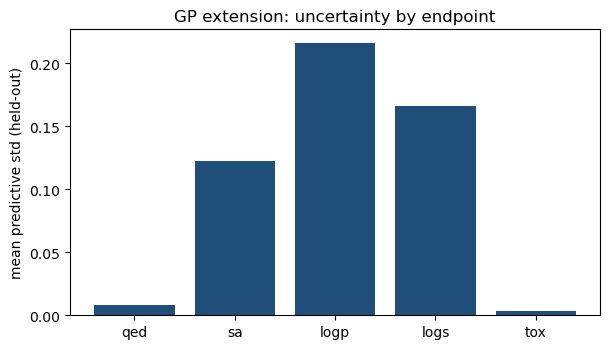

Saved: /Users/alighiami/Documents/Master/figures/06_gp_uncertainty.png
Interpretation: GP gives endpoint-wise uncertainty usable in acquisition (replace RF tree std).


In [16]:
# --- Extension A: Gaussian Process surrogate (PCA + GP) ---
# Full 2048-bit GP is impractical with few points; we reduce fingerprints with PCA.

def ensure_pkg(pkg, pip_name=None):
 import importlib, subprocess, sys
 try:
  return importlib.import_module(pkg)
 except ImportError:
  subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or pkg])
  return importlib.import_module(pkg)

from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

gp_pool = full_df[full_df["kept"]].drop_duplicates("smiles").reset_index(drop=True)
X_fp = np.vstack([fp_array(Chem.MolFromSmiles(s)) for s in gp_pool["smiles"]])
Y_gp = gp_pool[OBJ_COLS].values.astype(float)

n_comp = min(20, max(5, X_fp.shape[0] // 3))
pca = PCA(n_components=n_comp, random_state=42)
X_pca = StandardScaler().fit_transform(pca.fit_transform(X_fp))
print(f"PCA: {X_fp.shape[1]} bits -> {n_comp} comps ({100*pca.explained_variance_ratio_.sum():.1f}% var)")

Xtr, Xte, Ytr, Yte = train_test_split(X_pca, Y_gp, test_size=0.25, random_state=42)
kernel = ConstantKernel(1.0) * RBF(length_scale=2.0) + WhiteKernel(noise_level=0.05)
gp = MultiOutputRegressor(
 GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=1)
)
gp.fit(Xtr, Ytr)

# Per-target predictive std from each GP
means, stds = [], []
for i, est in enumerate(gp.estimators_):
 m, s = est.predict(Xte, return_std=True)
 means.append(m)
 stds.append(s)
Yhat = np.column_stack(means)
Ystd = np.column_stack(stds)

gp_metrics = []
for i, t in enumerate(OBJ_COLS):
 gp_metrics.append({
  "endpoint": t,
  "MAE": mean_absolute_error(Yte[:, i], Yhat[:, i]),
  "R2": r2_score(Yte[:, i], Yhat[:, i]),
  "mean_pred_std": float(Ystd[:, i].mean()),
 })
gp_metrics_df = pd.DataFrame(gp_metrics)
display(gp_metrics_df.round(3))
gp_metrics_df.to_csv(DATA / "extension_gp_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.bar(gp_metrics_df["endpoint"], gp_metrics_df["mean_pred_std"], color="#1f4e79")
ax.set_ylabel("mean predictive std (held-out)")
ax.set_title("GP extension: uncertainty by endpoint")
fig.tight_layout()
fig.savefig(FIG / "06_gp_uncertainty.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", FIG / "06_gp_uncertainty.png")
print("Interpretation: GP gives endpoint-wise uncertainty usable in acquisition (replace RF tree std).")


NSGA-II front-0 size: 20 | diverse subset kept: 12


,mutation,qed,sa,logp,logs,tox,crowding
2,methyl_add@1,0.847,2.398,3.463,-3.930,0.0,inf
44,gen2|ring_Cl@7,0.881,2.637,4.117,-4.555,0.0,inf
88,gen2|ring_OH@8,0.844,2.850,3.087,-3.726,0.0,inf
91,gen2|ring_OH@9,0.844,2.780,3.087,-3.726,0.0,inf
9,methyl_remove@11,0.795,1.559,2.512,-3.091,0.0,inf
39,gen2|methyl_remove@0,0.825,1.783,2.902,-3.489,0.0,0.711
11,ring_Cl@5,0.871,2.461,3.727,-4.156,0.0,0.570
27,gen2|methyl_remove@10,0.804,2.162,2.902,-3.357,0.0,0.519
72,gen2|ring_Cl@9,0.881,2.746,4.035,-4.438,0.0,0.481
62,gen2|methyl_add@4,0.865,2.179,3.556,-4.009,0.0,0.457


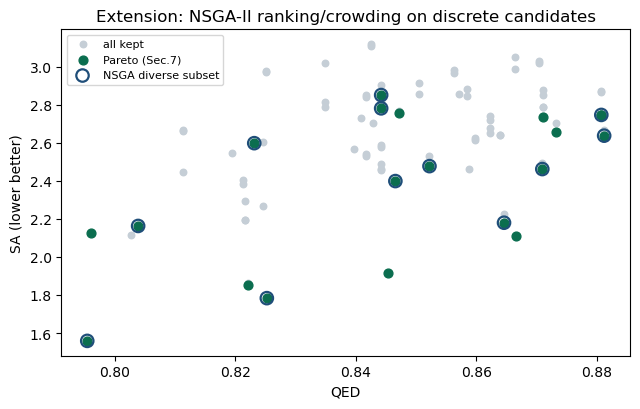

Saved: /Users/alighiami/Documents/Master/figures/07_nsga_subset.png
Note: full generative NSGA-II would also evolve new SMILES each generation; here we apply NSGA survival to the mutant pool.


In [17]:
# --- Extension B: NSGA-II style search on discrete mutants (pymoo) ---
pymoo = ensure_pkg("pymoo", "pymoo")
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Encode kept candidates; NSGA-II survival selects a diverse non-dominated subset
cand = full_df[full_df["kept"]].drop_duplicates("smiles").reset_index(drop=True)
F = objective_matrix(cand) # maximize all -> pymoo minimizes, so negate
F_min = -F

nds = NonDominatedSorting()
fronts = nds.do(F_min)
rank = np.empty(len(cand), dtype=int)
for r, fr in enumerate(fronts):
 rank[fr] = r

# Crowding distance on front 0 (pymoo helper via RankAndCrowding logic simplified)
front0 = fronts[0]
F0 = F_min[front0]
# crowding: sum of normalized neighbor gaps
crowd = np.zeros(len(front0))
for j in range(F0.shape[1]):
 order = np.argsort(F0[:, j])
 crowd[order[0]] = crowd[order[-1]] = np.inf
 lo, hi = F0[order[0], j], F0[order[-1], j]
 if hi - lo < 1e-12:
  continue
 for k in range(1, len(order) - 1):
  crowd[order[k]] += (F0[order[k + 1], j] - F0[order[k - 1], j]) / (hi - lo)

nsga_order = np.argsort(-crowd)
n_keep = min(12, len(front0))
nsga_sel = front0[nsga_order[:n_keep]]
nsga_df = cand.loc[nsga_sel].copy()
nsga_df["nsga_rank"] = 0
nsga_df["crowding"] = crowd[nsga_order[:n_keep]]

print(f"NSGA-II front-0 size: {len(front0)} | diverse subset kept: {len(nsga_df)}")
display(nsga_df[["mutation", "qed", "sa", "logp", "logs", "tox", "crowding"]].round(3).head(12))
nsga_df.to_csv(DATA / "extension_nsga_subset.csv", index=False)

# Compare RF/Pareto front vs NSGA diverse subset in QED-SA plane
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(cand["qed"], cand["sa"], c="#c5ced6", s=22, label="all kept")
ax.scatter(front["qed"], front["sa"], c="#0b6e4f", s=40, label="Pareto (Sec.7)")
ax.scatter(nsga_df["qed"], nsga_df["sa"], facecolors="none", edgecolors="#1f4e79", s=80, linewidths=1.6, label="NSGA diverse subset")
ax.set_xlabel("QED")
ax.set_ylabel("SA (lower better)")
ax.set_title("Extension: NSGA-II ranking/crowding on discrete candidates")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "07_nsga_subset.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", FIG / "07_nsga_subset.png")
print("Note: full generative NSGA-II would also evolve new SMILES each generation; here we apply NSGA survival to the mutant pool.")


,mutation,ehvi_2d,qed,sa,logp,logs
14,ring_Cl@6,0.0049,0.8709,2.4938,3.7266,-4.1563
32,gen2|ring_Cl@7,0.0022,0.8584,2.8801,4.1167,-4.4230
2,methyl_add@1,0.0016,0.8466,2.3982,3.4633,-3.9298
36,gen2|methyl_add@6,0.0014,0.8640,2.6392,3.7717,-4.2111
29,gen2|ring_Cl@6,0.0014,0.8584,2.8427,4.1167,-4.4230
55,gen2|ring_Cl@6,0.0012,0.8704,3.0209,4.2876,-4.5967
13,ring_F@6,0.0010,0.8522,2.5297,3.2123,-3.7303
42,gen2|ring_OH@6,0.0009,0.8471,2.7666,3.1689,-3.8435


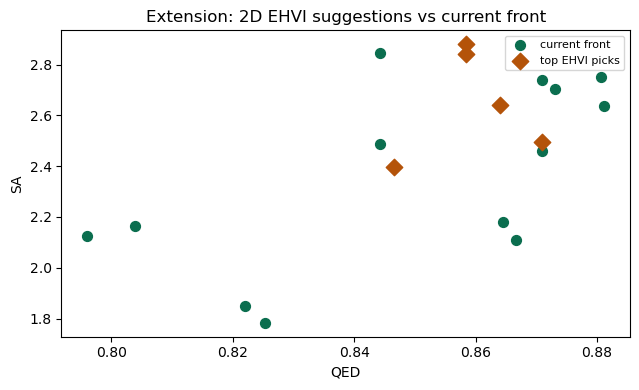

Saved: /Users/alighiami/Documents/Master/figures/08_ehvi_picks.png
Roadmap to qEHVI: replace this 2D MC estimate with BoTorch qEHVI on a multi-output GP; select a batch that jointly maximizes expected hypervolume.


In [18]:
# --- Extension C: 2D Expected Hypervolume Improvement (EHVI demo) ---
# Full qEHVI (batched, many objectives) typically uses BoTorch. Here we demonstrate
# Monte Carlo EHVI in 2D (QED maximize, SA minimize) using GP-like predictive samples
# from the RF ensemble already trained — conceptually the same acquisition family.

def hv2d_max(points, ref):
 return hypervolume_2d(points, ref)


def ehvi_2d_mc(mean_xy, std_xy, front_xy, ref, n_mc=64, rng=None):
 # Monte Carlo EHVI for maximize-maximize 2D predictions
 rng = np.random.default_rng(42 if rng is None else rng)
 base = hv2d_max(front_xy, ref)
 samples = rng.normal(mean_xy, np.maximum(std_xy, 1e-6), size=(n_mc, 2))
 vals = []
 for s in samples:
  vals.append(hv2d_max(np.vstack([front_xy, s]), ref) - base)
 return float(np.mean(np.maximum(vals, 0.0)))


# Build 2D front from labelled molecules used in the active loop
lab_now = final_lab.copy()
front_now = lab_now[lab_now["on_front"]]
front_xy = np.column_stack([front_now["qed"].to_numpy(float), -front_now["sa"].to_numpy(float)])
ref = np.array([0.3, -5.0])

# Candidate = unlabelled pool molecules; predict with latest RF surrogate on fingerprints
unlab = pool.drop(index=list(labelled_idx), errors="ignore")
if len(unlab) == 0:
 # fall back: use non-front kept molecules as "candidates"
 unlab = pareto_df[~pareto_df["on_front"]].copy()

model_ehvi = fit_surrogate(lab_now)
Xu = np.vstack([fp_array(Chem.MolFromSmiles(s)) for s in unlab["smiles"]])
mean_u, std_u = predict_with_uncertainty(model_ehvi, Xu)
# map to (QED, -SA)
mean_xy = np.column_stack([mean_u[:, 0], -mean_u[:, 1]])
std_xy = np.column_stack([std_u[:, 0], std_u[:, 1]])

n_cand = min(40, len(unlab))
ehvi_scores = [
 ehvi_2d_mc(mean_xy[i], std_xy[i], front_xy, ref, n_mc=64)
 for i in range(n_cand)
]
unlab = unlab.iloc[:n_cand].copy()
ehvi_df = unlab.copy()
ehvi_df["ehvi_2d"] = ehvi_scores
ehvi_df = ehvi_df.sort_values("ehvi_2d", ascending=False)
display(ehvi_df[["mutation", "ehvi_2d", "qed", "sa", "logp", "logs"]].head(8).round(4))
ehvi_df.head(20).to_csv(DATA / "extension_ehvi_top.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.scatter(front_xy[:, 0], -front_xy[:, 1], c="#0b6e4f", s=50, label="current front")
top = ehvi_df.head(5)
ax.scatter(top["qed"], top["sa"], c="#b45309", s=70, marker="D", label="top EHVI picks")
ax.set_xlabel("QED")
ax.set_ylabel("SA")
ax.set_title("Extension: 2D EHVI suggestions vs current front")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "08_ehvi_picks.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", FIG / "08_ehvi_picks.png")
print("Roadmap to qEHVI: replace this 2D MC estimate with BoTorch qEHVI on a multi-output GP; select a batch that jointly maximizes expected hypervolume.")


## 10.1 Extension conclusions

| Method | Role in MolParetoBO | Status in this notebook |
|--------|---------------------|-------------------------|
| RF + scalar acquisition | Minimal viable active loop | **Core (done)** |
| GP (+ PCA) | Better uncertainty | **Extension A (runnable)** |
| NSGA-II ranking | Diversity on the front | **Extension B (runnable)** |
| 2D EHVI | Hypervolume-aware acquisition | **Extension C (runnable demo)** |
| qEHVI / BoTorch | Batched BO in many objectives | **Future work** |

These extensions show that the student understands the research-grade upgrades without requiring them for the minimal successful version.


## Appendix A — How to run

### Local (Anaconda)
```bash
jupyter notebook MolParetoBO_Report.ipynb
# or: jupyter lab MolParetoBO_Report.ipynb
python build_attractive_report.py
python build_slides.py
```

### Google Colab
1. Upload `MolParetoBO_Report.ipynb` (and optionally `requirements.txt`)
2. Runtime → **Run all**
3. Scroll to **Section 8c — Interactive Control Panel** and click buttons 1–5

### Deliverables
- [x] Notebook workflow + widgets
- [x] Report PDF
- [x] Presentation slides (PDF + PPTX)
- [x] Tools documentation (Appendix B)


## Appendix B — Tools & software (detailed)

This project was implemented with the following stack. Versions below are from the development environment; Colab may resolve slightly newer wheels via `pip`.

### B.1 Core cheminformatics & science stack

| Tool | Role in MolParetoBO | Details |
|------|---------------------|---------|
| **Python 3** | Main language | Notebook + scripts |
| **RDKit** | Molecules, mutations, descriptors | SMILES parse/sanitize; edit mols (methyl add/remove, ring F/Cl/OH/Me); QED, Crippen logP, MW; Morgan fingerprints; 2D drawing (`Draw`) |
| **RDKit SA Score** (`rdkit.Contrib.SA_Score`) | Synthetic accessibility oracle | Ertl & Schuffenhauer SA score |
| **NumPy** | Arrays / numerics | Fingerprint matrices, Pareto masks, MC-EHVI samples |
| **pandas** | Tables | Scored mutants, fronts, history CSVs |
| **matplotlib** | Figures | Parity plots, Pareto projections, loop progress, extension plots |

### B.2 Machine learning & multi-objective

| Tool | Role | Details |
|------|------|---------|
| **scikit-learn** | Surrogates & metrics | `RandomForestRegressor` + `MultiOutputRegressor`; train/test split; MAE / R²; **PCA** + **GaussianProcessRegressor** (extension A); fingerprint feature matrices |
| **pymoo** | NSGA-II utilities (extension B) | `NonDominatedSorting` + crowding on discrete mutant pool |
| **Custom NumPy EHVI** | Hypervolume-aware acquisition demo | 2D Monte Carlo EHVI (extension C); full **qEHVI** would use BoTorch (future work, not required) |

### B.3 Interactivity & delivery

| Tool | Role | Details |
|------|------|---------|
| **ipywidgets** | Interactive UI | Sliders, dropdowns, buttons, output panels — Sections **5b**, **6**, **8b**, **8c** |
| **IPython / Jupyter** | Notebook runtime | Local Anaconda or **Google Colab** |
| **Google Colab** | Remote runnable demo | Setup cell installs deps; `enable_custom_widget_manager()` for widgets |
| **python-pptx** | Presentation | Builds `MolParetoBO_Slides.pptx` |
| **Chrome headless** | PDF export | Prints HTML report/slides to `MolParetoBO_Report.pdf` / `MolParetoBO_Slides.pdf` |

### B.4 Project scripts (this repository)

| Script / file | Purpose |
|---------------|---------|
| `MolParetoBO_Report.ipynb` | Living report + all executable code + widgets |
| `build_attractive_report.py` | Regenerates styled HTML/PDF technical report |
| `build_slides.py` | Regenerates PPTX + PDF slides |
| `requirements.txt` | Pip dependencies for Colab/local |
| `data/*.csv` | Seed scores, mutants, Pareto, history, extensions |
| `figures/*.png` | All report/slide figures |

### B.5 Oracle endpoints — how each is computed

| Endpoint | Library / method |
|----------|------------------|
| QED | `rdkit.Chem.QED` |
| SA | `sascorer.calculateScore` (RDKit Contrib) |
| logP | `rdkit.Chem.Crippen.MolLogP` |
| logS | ESOL-style formula from MW, logP, rotatable bonds, aromatic fraction |
| Tox proxy | Custom SMARTS alerts + soft MW/logP penalties (teaching proxy) |

### B.6 What to click

1. Open `MolParetoBO_Report.ipynb` (local or Colab) → **Run all** 
2. Go to **Section 8c — Interactive Control Panel** 
3. Press buttons **1 → 5**; each should show a green **OK** banner 
4. Optionally open `MolParetoBO_Slides.pdf` for the oral presentation 

### B.7 Versions used while building this report

| Package | Version (dev machine) |
|---------|------------------------|
| RDKit | 2025.03.3 |
| scikit-learn | 1.5.1 |
| ipywidgets | 7.8.1 |
| pymoo | 0.6.2 |
| pandas | 2.2.2 |
| NumPy | 1.26.4 |
| matplotlib | 3.9.2 |
